In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS, get_trained_agent
from sac.trainer import HockeyTrainer, SCORE_REWARD, DEFAULT_REWARD
from sac.tournament import PooledTournament

In [2]:
params = SB3_PARAMS
hidden_sizes = [128, 128]
params["alpha"] = 0.1
params["hidden_sizes"] = hidden_sizes

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/small-{random_seed}"

In [6]:
trainer = HockeyTrainer(params, reward_func=DEFAULT_REWARD)
weak_opponent = h_env.BasicOpponent(weak=True)
strong_opponent = h_env.BasicOpponent(weak=False)

In [7]:
# trainer.load("./agents/strongcont-0", episode=5000)

In [8]:
tournament = PooledTournament(seed=random_seed)
tournament.add_agent(weak_opponent)
tournament.add_agent(strong_opponent)

In [9]:
agent_paths = [
    "./agents/reward-0-5000.pth",
    "./agents/continue-0-10000.pth",
    "./agents/selfplay-0-5000.pth",
    "./agents/strong-0-7000.pth",
    "./agents/strongcont-0-5000.pth",
    "./agents/strongcont-0-5500.pth",
]
for agent_path in agent_paths:
    new_agent = get_trained_agent(agent_path)
    tournament.add_agent(new_agent)

In [10]:
trainer.warmup(256)

In [11]:
max_timesteps = 500
new_episodes = 500
log_interval = 20
train_interval = 20

In [12]:
def evaluate_agent(trainer, opponent):
    rewards, scores = trainer.evaluate(opponent, 100, render=False)
    print("Avg reward:",np.mean(rewards))
    print("Winrate:",0.5 * (np.mean(scores)+1))
    print("Winrate (no ties):", np.mean(np.asarray(scores) == 1))

In [13]:
def add_agent(trainer, tournament, params):
    new_agent = trainer.create_agent(params)
    agent_state = trainer.agent.state()
    new_agent.restore_state(agent_state)
    tournament.add_agent(new_agent)

In [14]:
for i in range(5):
    trainer.train(tournament, new_episodes, train_interval, log_interval, max_timesteps)
    evaluate_agent(trainer, weak_opponent)
    evaluate_agent(trainer, strong_opponent)
    trainer.save_agent(filepath)
    add_agent(trainer, tournament, params)

    20: Reward:  -21.946 Winrate:    0.250
    40: Reward:  -17.641 Winrate:    0.275
    60: Reward:  -18.026 Winrate:    0.325
    80: Reward:  -21.118 Winrate:    0.275
   100: Reward:  -19.926 Winrate:    0.350
   120: Reward:  -22.230 Winrate:    0.375
   140: Reward:  -24.060 Winrate:    0.300
   160: Reward:  -19.756 Winrate:    0.325
   180: Reward:  -19.254 Winrate:    0.375
   200: Reward:  -21.222 Winrate:    0.300
   220: Reward:  -18.364 Winrate:    0.150
   240: Reward:  -21.406 Winrate:    0.300
   260: Reward:  -18.253 Winrate:    0.125
   280: Reward:  -13.931 Winrate:    0.225
   300: Reward:  -14.404 Winrate:    0.225
   320: Reward:  -11.775 Winrate:    0.425
   340: Reward:  -11.639 Winrate:    0.325
   360: Reward:  -16.054 Winrate:    0.350
   380: Reward:  -15.354 Winrate:    0.200
   400: Reward:  -16.080 Winrate:    0.350
   420: Reward:  -15.606 Winrate:    0.300
   440: Reward:  -14.827 Winrate:    0.200
   460: Reward:  -15.878 Winrate:    0.300
   480: Rew

In [15]:
trainer.evaluate(weak_opponent, render=True)

([-4.873966680391604,
  -12.788898314942106,
  -4.25251443727164,
  -12.538984488478084,
  -5.544481033851909],
 [0, -1, 0, -1, 0])

In [19]:
trainer.evaluate(strong_opponent, render=True)

([8.106655978363245,
  9.391697434960612,
  9.56174165805288,
  7.650976940835361,
  8.703714995676364],
 [1, 1, 1, 1, 1])

In [16]:
trainer.reset()

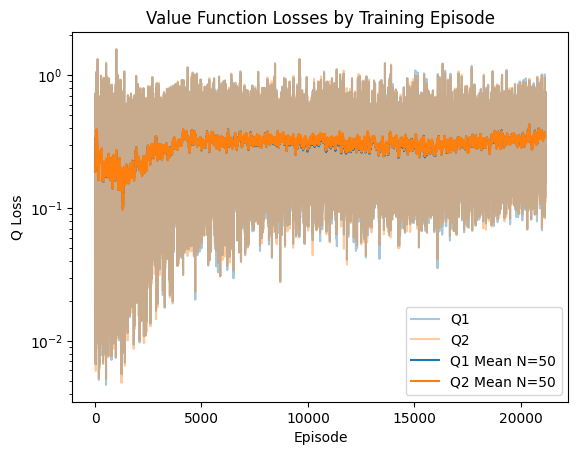

In [17]:
q_losses = np.stack([trainer.logs["Q1_loss"], trainer.logs["Q2_loss"]]).T
plot_q(q_losses, "./results")

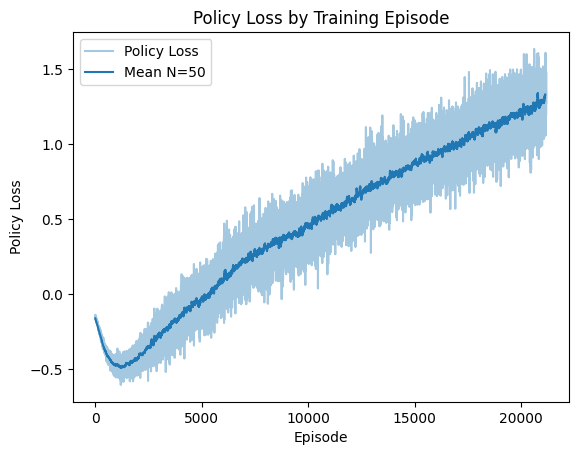

In [18]:
plot_policy_loss(trainer.logs["Policy_loss"], "./results")

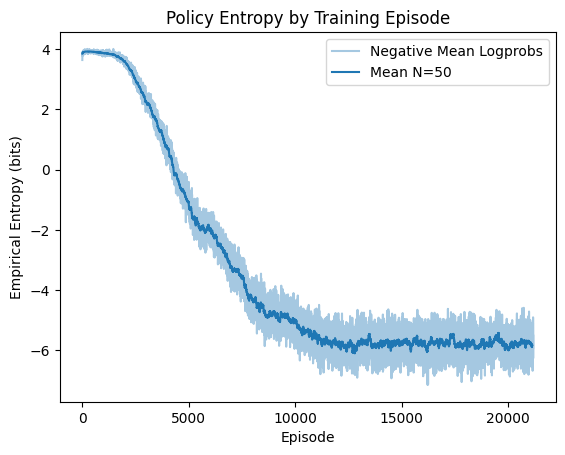

In [19]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

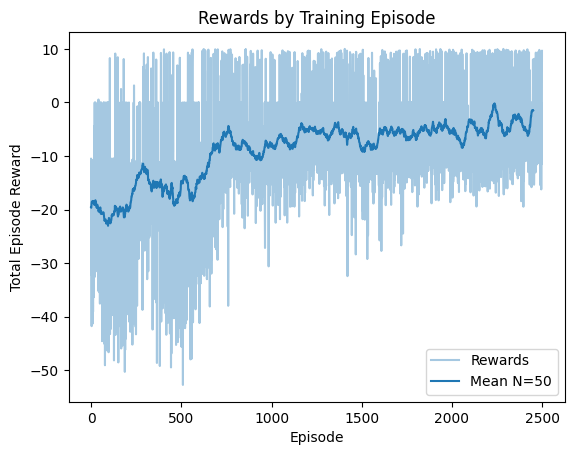

In [20]:
plot_rewards(trainer.logs["Rewards"], "./results")

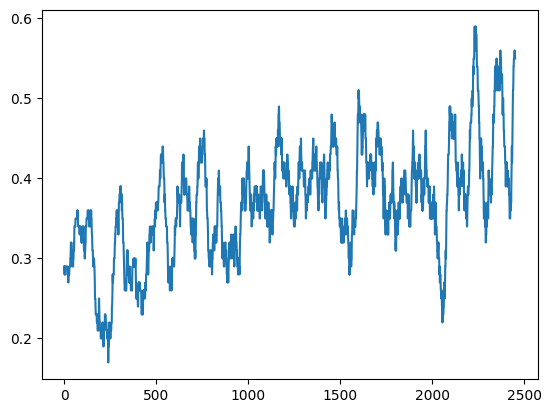

In [21]:
plt.plot(running_mean(0.5*(np.asarray(trainer.logs["Scores"])+1), 50))

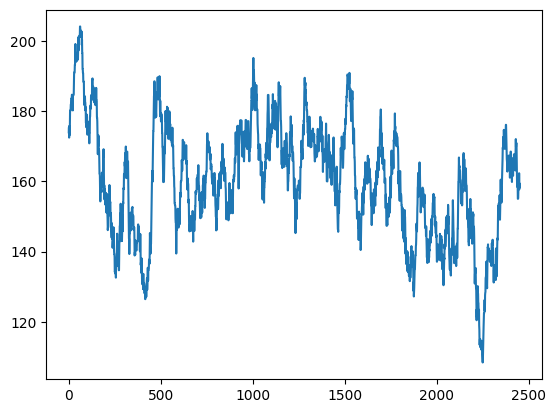

In [22]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))

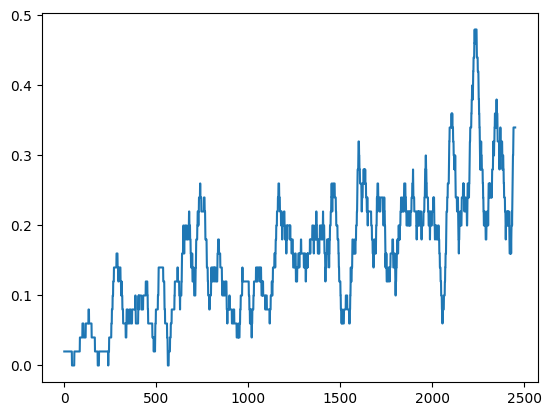

In [23]:
plt.plot(running_mean(np.asarray(trainer.logs["Scores"]) == 1, 50))